In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,BatchNormalization,Dropout,GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import EfficientNetB0

In [3]:
train_dir = "few_shot_dataset/train"
val_dir = "few_shot_dataset/test"
test_dir = "few_shot_dataset/val"

In [22]:
print(len(train_dir))
print(len(val_dir))
print(len(test_dir))

22
21
20


In [4]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 4

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    shear_range=0.1
)
val_datagen=ImageDataGenerator(rescale=1./255)
test_datagen=ImageDataGenerator(rescale=1./255)

# =============================
# TRAIN DATA
# =============================
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # because you have 6 classes
    shuffle=True
)


# =============================
# VALIDATION DATA
# =============================
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# =============================
# TEST DATA
# =============================
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 55 images belonging to 6 classes.
Found 50 images belonging to 6 classes.
Found 33 images belonging to 6 classes.


In [6]:
conv_base= EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 381s 23us/step


In [7]:
conv_base.trainable=False

In [8]:
# Apply Data Augmentation on train data.
train_datagen=ImageDataGenerator(rescale=1./255,
                                 horizontal_flip=True,
                                 rotation_range=20,
                                 zoom_range=0.2,
                                 validation_split=0.2   # split Our 20% of tranning data into validation data(because we don't have validation data).
                                )
# Train data 
train_generator=train_datagen.flow_from_directory(train_dir,
                                    target_size=(128,128),
                                    batch_size=16,
                                    shuffle=True,
                                    seed=42,
                                    class_mode='categorical' 
                                    )
# Validation data
validation_generator=train_datagen.flow_from_directory(val_dir,
                                  target_size=(128,128),
                                  batch_size=16,                                  
                                  class_mode='categorical',
                                  seed=42)
# Test data
test_datagen=ImageDataGenerator(rescale=1./255)                 #Scale test data
test_generator=test_datagen.flow_from_directory(test_dir,
                                        target_size=(128,128),
                                        batch_size=16,
                                        shuffle=False,
                                        class_mode='categorical')

Found 55 images belonging to 6 classes.
Found 50 images belonging to 6 classes.
Found 33 images belonging to 6 classes.


In [9]:
model=Sequential([
    conv_base,
    Flatten(),
    Dense(32,activation='relu'),
    Dense(6,activation='sigmoid')
])

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 4, 4, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 20480)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │         655,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             198 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,705,161 (17.95 MB)

 Trainable params: 655,590 (2.50 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
# Compile and train model:
# Optimizer:Adam

opt=tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=opt,loss=tf.keras.losses.binary_crossentropy,metrics=['accuracy'])

In [12]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
es=EarlyStopping(monitor='val_loss',patience=5,verbose=1)
reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3)

cb=[es,reduce_lr]

In [21]:

hist=model.fit(
    train_generator,
    epochs=100,verbose=1,
    validation_data=validation_generator,
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 954ms/step - accuracy: 0.1818 - loss: 0.5084 - val_accuracy: 0.1800 - val_loss: 0.4675
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 731ms/step - accuracy: 0.1818 - loss: 0.4830 - val_accuracy: 0.0800 - val_loss: 0.5246
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 804ms/step - accuracy: 0.1455 - loss: 0.4883 - val_accuracy: 0.1800 - val_loss: 0.4674
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 725ms/step - accuracy: 0.1091 - loss: 0.4766 - val_accuracy: 0.3000 - val_loss: 0.4462
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 767ms/step - accuracy: 0.1455 - loss: 0.4623 - val_accuracy: 0.1600 - val_loss: 0.4618
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 837ms/step - accuracy: 0.1818 - loss: 0.4684 - val_accuracy: 0.3600 - val_loss: 0.4373
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 716ms/step - accuracy: 0.2364 - loss: 0.4816 - val_accuracy: 0.2000 - val_loss: 0.4485
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 722ms/step - accuracy: 0.1455 - loss: 0.4851 - val_accuracy: 0.1600 - v

In [15]:
import matplotlib.pyplot as plt
import  numpy as np

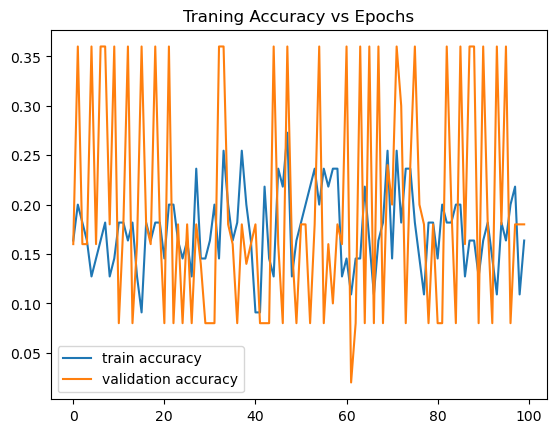

In [16]:
plt.title('Traning Accuracy vs Epochs')
plt.plot(hist.history['accuracy'],label='train accuracy')
plt.plot(hist.history['val_accuracy'],label='validation accuracy')
plt.legend()
plt.show()

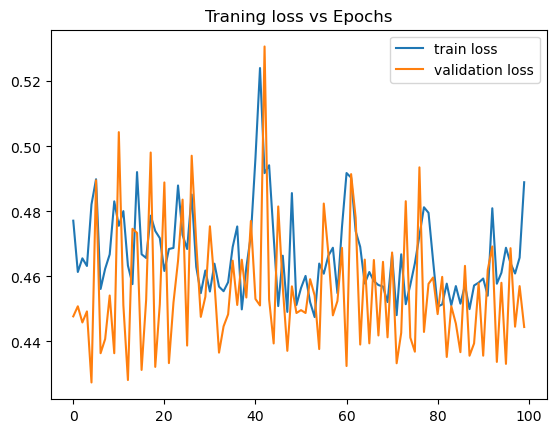

In [17]:
plt.title('Traning loss vs Epochs')
plt.plot(hist.history['loss'],label='train loss')
plt.plot(hist.history['val_loss'],label='validation loss')
plt.legend()
plt.show()

In [18]:
prediction=model.predict(test_generator)

3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step


In [19]:
y_pred = np.argmax(prediction, axis=1)
y_true=test_generator.classes
print(len(y_true))
print(len(y_pred))

33
33


C:\Users\Kinza\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Test Accuracy:0.15151515151515152
Test Precision:0.026041666666666668
Test Recall:0.16666666666666666
Test F1:0.04504504504504505


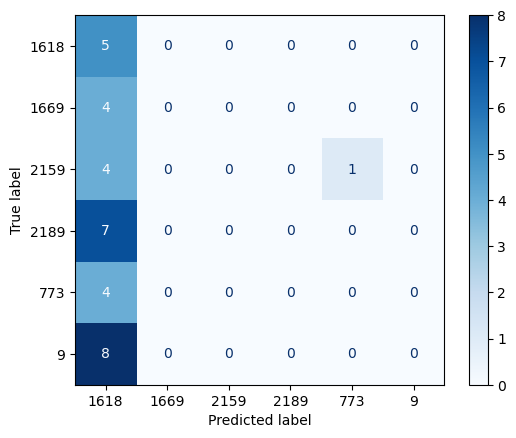

In [20]:
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
acc=accuracy_score(y_true,y_pred)
pre=precision_score(y_true,y_pred,average='macro')
re=recall_score(y_true,y_pred,average='macro')
fs=f1_score(y_true,y_pred,average='macro')
cm=confusion_matrix(y_true,y_pred)
print(f'Test Accuracy:{acc}')
print(f'Test Precision:{pre}')
print(f'Test Recall:{re}')
print(f'Test F1:{fs}')
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=validation_generator.class_indices.keys())
disp.plot(cmap='Blues')
plt.show()